In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Ligue1_lens_data import get_team_stats

plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams['axes.unicode_minus'] = False


In [2]:
df = pd.read_csv('https://www.football-data.co.uk/mmz4281/2526/F1.csv')
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,F1,15/08/2025,19:45,Rennes,Marseille,1,0,H,0,0,...,1.95,1.90,1.94,1.98,1.95,1.97,1.86,1.89,1.97,2.02
1,F1,16/08/2025,16:00,Lens,Lyon,0,1,A,0,1,...,1.80,2.05,1.76,2.18,1.82,2.10,1.77,2.02,1.86,2.15
2,F1,16/08/2025,18:00,Monaco,Le Havre,3,1,H,1,0,...,2.00,1.85,2.10,1.79,2.05,1.85,1.96,1.77,2.07,1.88
3,F1,16/08/2025,20:05,Nice,Toulouse,0,1,A,0,0,...,1.98,1.88,2.14,1.78,1.98,1.93,1.93,1.83,2.06,1.92
4,F1,17/08/2025,14:00,Brest,Lille,3,3,D,1,2,...,2.10,1.78,2.29,1.68,2.12,1.78,2.02,1.70,2.22,1.79


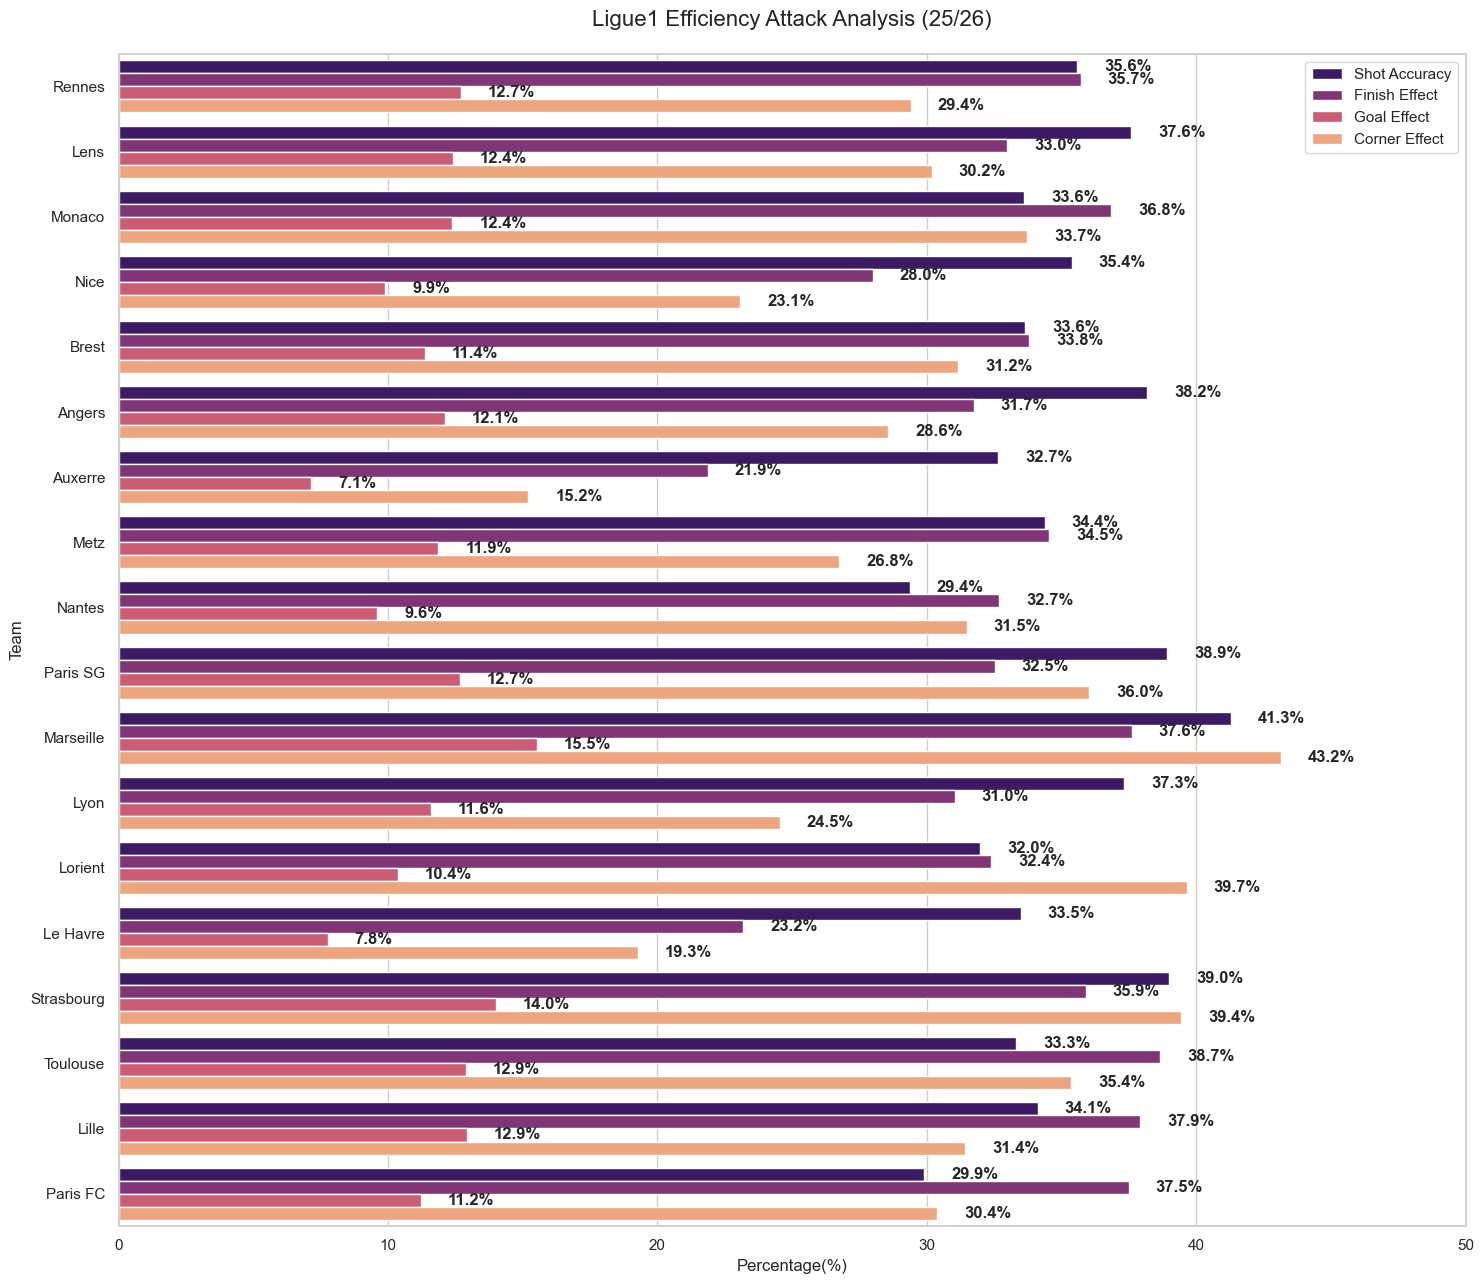

In [3]:
# 1. 데이터에 있는 모든 팀 이름을 중복 없이 가져오기
all_teams = df['HomeTeam'].unique()
results = []

# df_teams = df[['HomeTeam','AwayTeam','FTHG','FTAG','FTR','HS','AS','HST','AST']] # 홈, 원정, 홈 득점, 원정 득점, 승무패, 홈 슈팅, 원정 슈팅, 홈 유효슈팅, 원정 유효슈팅

# 2. for문으로 모든 팀을 하나씩 분석
for team in all_teams:
  team_list = get_team_stats(df, team)
  results.extend(team_list)

df_compare = pd.DataFrame(results)

# 그래프 스타일 설정
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15,13))

# 3. 가로형 바 그래프 (18개 팀 전체)
ax = sns.barplot(
  data=df_compare, 
  x='Value (%)', 
  y='Team', 
  hue='Metric', # 색상을 구분할 기준
  palette='magma', 
  legend=True # 범례 사용할시 True로
  )

# 수치 표시
for p in ax.patches: # p는 각 막대(객체)를 의미
  # width : 막대의 가로 길이(Value(%)값)를 가져옴
  width = p.get_width()
  if width > 0: # 0보다 큰 값일 때만 텍스트를 그립니다
    # plt.text(x좌표, y좌표, 표시할 내용, 옵션)
    plt.text(
      width + 1, # 막대 끝에서 1만큼 오른쪽 여백
      p.get_y() + p.get_height()/2, # 막대의 세로 위치(y)에서 높이의 절반을 더해 '중앙에 맞춤
      f'{width:.1f}%', # width 값을 소수점 첫째 자리까지 문자열로 포맷팅
      va='center',  # 수직 정렬을 중앙으로 설정
      fontweight='bold' # 글씨는 굵게
    )


# 타이틀을 포함 마무리 
plt.title("Ligue1 Efficiency Attack Analysis (25/26)",fontsize=16, pad=20)
plt.xlabel('Percentage(%)')
plt.xlim(0, 50) # 수치 표시 공간 확보
plt.tight_layout()

plt.legend()
plt.show()